In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.DataFrame({'Age': [20,21,22,23,24,25,26,27,28,29,30,50]})
df

,Age
0,20
1,21
2,22
3,23
4,24
5,25
6,26
7,27
8,28
9,29


In [6]:
mean = np.mean(df['Age'])
std = np.std(df['Age'])

df['Z-score'] = (df['Age'] - mean) /std
df

,Age,Z-score
0,20,-0.938954
1,21,-0.806396
2,22,-0.673838
3,23,-0.541280
4,24,-0.408721
5,25,-0.276163
6,26,-0.143605
7,27,-0.011047
8,28,0.121512
9,29,0.254070


In [7]:
# Print the data
print(f"Data with outliers : \n{df}")

Data with outliers : 
    Age   Z-score
0    20 -0.938954
1    21 -0.806396
2    22 -0.673838
3    23 -0.541280
4    24 -0.408721
5    25 -0.276163
6    26 -0.143605
7    27 -0.011047
8    28  0.121512
9    29  0.254070
10   30  0.386628
11   50  3.037793


In [8]:
# print the outliers
print(f"Outliers based on the z-score threshold \n{df[df['Z-score'] > 3]}")

Outliers based on the z-score threshold 
    Age   Z-score
11   50  3.037793


In [9]:
# Remove the outliers
df = df[df['Z-score'] <= 3]

In [10]:
print(f"Data without outliers : \n {df}")

Data without outliers : 
     Age   Z-score
0    20 -0.938954
1    21 -0.806396
2    22 -0.673838
3    23 -0.541280
4    24 -0.408721
5    25 -0.276163
6    26 -0.143605
7    27 -0.011047
8    28  0.121512
9    29  0.254070
10   30  0.386628


In [11]:
import numpy as np
from scipy import stats

In [16]:
df2 = [2.5,2.7,2.8,3.0,3.2,3.4,3.6,3.8,4.0,110.0]
Z_score = np.abs(stats.zscore(df2))

In [17]:
threshold = 2.5
outliers = np.where(Z_score > threshold)[0]

In [18]:
print("Data", df2)

Data [2.5, 2.7, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 110.0]


In [21]:
print("Outliers:", [df2[i] for i in outliers])

Outliers: [110.0]


In [22]:
# Remove Outliers
df2 = [df2[i] for i in range(len(df2)) if i not in outliers]
print("Data without outliers : ", df2)

Data without outliers :  [2.5, 2.7, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0]


# K Means clustering

In [24]:
from sklearn.cluster import KMeans

In [25]:
data = [[2,-2],[3,-3],[4,-4],[30,-30],[31,-31],[32,-32]]
kmeans = KMeans(n_clusters=2, n_init=10)
kmeans.fit(data)

KMeans(n_clusters=2, n_init=10)

In [ ]:
labels = kmeans.predict(data)
outliers = 

# IQR

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

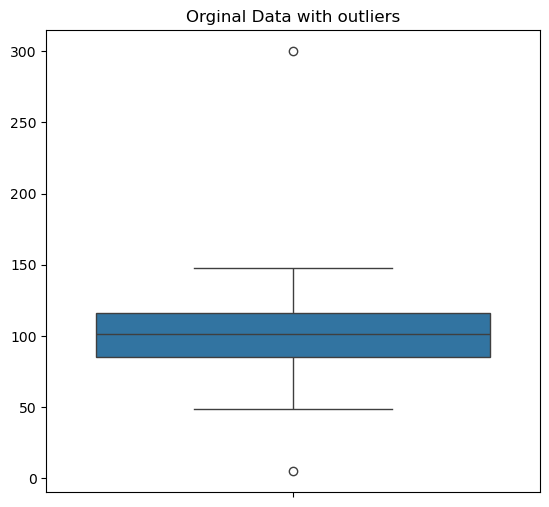

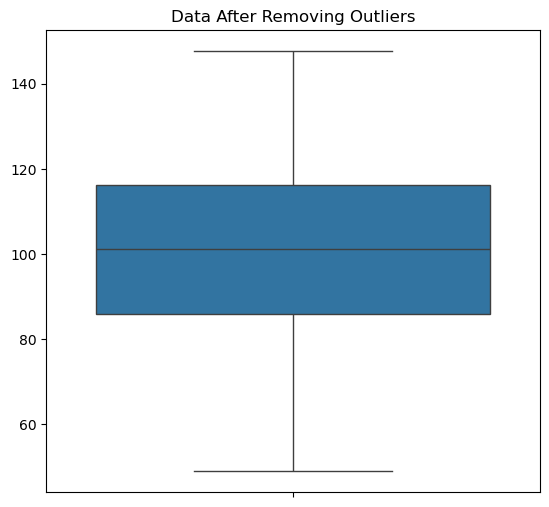

In [33]:
np.random.seed(0)
data = np.random.normal(100,20,200)
data = np.append(data, [300,5])

Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (data < lower_bound) | (data > upper_bound)

data_no_outliers = data[~outliers]

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.boxplot(data=data)
plt.title('Orginal Data with outliers')
plt.show()

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.boxplot(data=data_no_outliers)
plt.title('Data After Removing Outliers')
plt.show()